# Pairs trading on minute bars — II. Intraday walk-forward: which design survives out of fold?

## `pairs_trading_16_intraday_backtest.ipynb`

Notebook 15 established the candidates and the facts that matter: the cointegrated spreads of liquid
large caps revert over **weeks** (half-life ≈ 20 sessions) at every sampling interval, microstructure
noise is mild, about 40% of the spread's variance happens overnight, and a round trip costs ≈ 8 bps
against a reversion worth 16 bps with a one-hour look-back or 130 bps with a five-session one.

This notebook asks which intraday design earns money **out of fold** on the training span (2022–2024),
using the lesson of notebook 05: one pooled objective, few knobs, every fold's signal built only from its
own past. The knobs, in the order they are examined:

1. **Hedge estimation** — static OLS per fold, a daily-cadence Kalman filter applied intraday, an
   intraday Kalman filter with the noise scaled to the bar frequency, and the naive port of the daily
   Kalman settings to minute bars.
2. **Sampling frequency** — 1, 5, 15 and 30-minute bars, against the same pairs and folds traded on
   session closes (the daily-bar baseline).
3. **Session rule** — carry positions overnight, or flatten before the close and never enter late.
4. **Look-back and entry threshold** — a small grid, read with the winner's curse in mind.

The 2025 hold-out is untouched; notebook 17 spends it once. The cold run takes about 10 minutes on 16
cores (most of it the naive Kalman port); fitted states are cached under `notebooks/cache/`, and a warm
run takes about a minute.

Two mechanics matter for reading the tables. The pooled out-of-fold Sharpe over these 25 folds
(500 sessions, 2023-01 → 2024-12) has a standard error of roughly $\sqrt{252/500} \approx 0.7$, so
differences below one unit are not evidence. And the signal generator only opens a position while $z_\text{entry} \le |z| <
z_\text{stop}$ — at or beyond the stop level it stays flat rather than entering and being stopped out
on the next bar; on slow-moving intraday z-scores the alternative produces hundreds of one-bar round
trips during a single excursion. This rule was added to the package while building this notebook.

## 0. Setup

In [1]:
from pathlib import Path
import os, sys, time, json, pickle, warnings, itertools

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")
for _v in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS", "OMP_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # one BLAS thread per joblib worker

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

import pairs
from pairs import (load_universe, load_minute_bars, summarize_sessions, find_cointegrated_pairs_dualgate,
                   filter_kf_on_new, generate_pair_signals, evaluate_pair_signals, estimate_halflife,
                   estimate_halflife_window, session_masks, walk_forward_session_splits)
from pairs.models.kalman import _kalman_dynamic_hedge

LAKE        = Path(os.environ.get("MINUTE_LAKE", Path.home() / "local/parquet_lake/minute_adj"))
TICKER_ROOT = LAKE / "spx_ndx_combined_adjusted"
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)

START, TRAIN_END, END = "2022-01-03", "2024-12-31", "2025-08-13"
UNIVERSE, N_CANDIDATES = "spx_ndx_combined", 24
TRADED_SHARE_MIN, DOLLAR_VOLUME_MIN = 0.95, 20e6

BARS = {1: 390, 5: 78, 15: 26, 30: 13, "session": 1}     # bars per session by sampling frequency
TRAIN_SESSIONS, TEST_SESSIONS = 250, 20                    # ~1 year of sessions to fit, 4 weeks to test
CAP = 10_000                                               # $ per pair, dollar-neutral
COMMISSION_BPS = 1.0                                       # per leg per side, on top of the Roll half-spread
BORROW_BPS = 50
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})
print("pairs", pairs.__version__)

pairs 0.1.0


## 1. Data

Everything comes from the caches notebook 15 writes; if they are missing they are rebuilt here with the
same calls (universe pass → liquidity rule → dual-gate screen on training-span session closes → 1-minute
bars for the candidate tickers).

In [2]:
def ensure_caches():
    f_sessions, f_screen, f_cand, f_1m = (CACHE / n for n in ("min_sessions.parquet", "min_screen.parquet", "min_candidates.parquet", "min_candidates_1m.parquet"))
    universe = load_universe(UNIVERSE)
    if not f_sessions.exists():
        load_minute_bars(universe, START, END, TICKER_ROOT, freq="session").to_parquet(f_sessions)
    sessions = pd.read_parquet(f_sessions)
    summary = summarize_sessions(sessions)
    full = summary[summary["n_sessions"] == sessions.index.get_level_values("datetime").nunique()]
    liquid = full[(full["traded_share"] >= TRADED_SHARE_MIN) & (full["median_dollar_volume"] >= DOLLAR_VOLUME_MIN)]
    if not f_cand.exists():
        if not f_screen.exists():
            closes = sessions.loc[pd.IndexSlice[liquid.index, :], ["close"]]
            closes = closes[closes.index.get_level_values("datetime") <= pd.Timestamp(TRAIN_END)]
            find_cointegrated_pairs_dualgate(closes, alpha_eg=0.05, alpha_joh=0.05, fdr_method="bh", show_progress=False).to_parquet(f_screen)
        screen = pd.read_parquet(f_screen)
        screen[screen["verdict"] == "pass"].sort_values("eg_p_fdr").head(N_CANDIDATES).to_parquet(f_cand)
    candidates = pd.read_parquet(f_cand)
    tickers = sorted({t for p in candidates.index for t in p})
    if not f_1m.exists():
        load_minute_bars(tickers, START, END, TICKER_ROOT, freq="1min").to_parquet(f_1m)
    bars_1m = pd.read_parquet(f_1m)
    return sessions, liquid, candidates, bars_1m

sessions, liquid, candidates, bars_1m = ensure_caches()
PAIRS = list(candidates.index)
close_1m = bars_1m["close"].unstack("ticker")
sess_close = sessions["close"].unstack("ticker")[close_1m.columns]
roll_bps = liquid["median_roll_bps"].reindex(close_1m.columns)
cost_bps = {p: COMMISSION_BPS + 0.5 * roll_bps[list(p)].mean() for p in PAIRS}   # per leg per side: commission + half the Roll spread
print(f"{len(PAIRS)} candidate pairs on {close_1m.shape[1]} tickers; {close_1m.shape[0]:,} minutes over {close_1m.index.normalize().nunique()} sessions")
print("cost per leg per side (bps):", pd.Series(cost_bps).round(2).describe()[["min", "50%", "max"]].to_dict())
candidates[["eg_p_fdr", "joh_stat"]].round(4).T

10 candidate pairs on 14 tickers; 352,080 minutes over 906 sessions
cost per leg per side (bps): {'min': 2.69, '50%': 2.875, 'max': 3.0}


ticker1      PYPL       GM     PYPL     APTV     TROW                    \
ticker2       TSN      WFC      TFC       WM      USB       VZ      WFC   
eg_p_fdr   0.0001   0.0079   0.0188   0.0241   0.0241   0.0266   0.0266   
joh_stat  41.5169  41.4426  42.3262  36.3704  41.1922  40.1678  35.0331   

ticker1       JPM     TROW     PYPL  
ticker2      NFLX      VTR      XEL  
eg_p_fdr   0.0309   0.0309   0.0432  
joh_stat  32.3640  35.4487  41.7032

## 2. The walk-forward engine

Folds are counted in **sessions** (`walk_forward_session_splits`) over the training span only: 250
sessions to fit, the next 20 to trade, then advance 20 — so the test folds tile 2023-01 → 2024-12
without overlap and their P&L can be pooled into one out-of-fold series per pair. The fold boundaries are the same at every sampling
frequency, including "session closes", which makes the daily-bar baseline exactly comparable.

**Hedges** (each fitted on the training sessions only):

| name | hedge ratio in the test fold |
|---|---|
| `static` | OLS of $P_1$ on $P_2$ over the training bars, frozen |
| `daily_kalman` | the daily Kalman filter of the earlier notebooks (`q=1e-5`, EM 5) run on **session closes**; each session's bars use the state filtered at the *previous* close, so the hedge is updated once a day and is known before the open |
| `bar_kalman` | the same state-space model on the bars themselves, with the transition noise scaled to the bar frequency (`q = 1e-5 / bars per session`, so the hedge random walk has the same variance *per day*) and no EM |
| `bar_kalman_naive` | the daily settings (`q=1e-5`, EM 5) applied to the bars unchanged — what a straight port of notebook 02 would do |

The z-score look-back is chosen from the training residual (3 × half-life, clipped below at one session
or twenty bars, whichever is longer, and above at thirty sessions) and warmed up on the last 60 sessions of that residual — the robust estimator chains two rolling
medians and needs two windows of history — so a test fold never informs its own z-score; the same robust
z-score, next-bar execution and dollar-neutral $10{,}000 sizing as notebook 02 apply. Folds are
**stitched**: the position held at the end of one fold is carried into the next (`initial_position`),
re-sized to the new hedge ratio on its first bar, and the whole out-of-fold path of each pair is
evaluated once, so multi-week trades are neither truncated nor restarted at fold boundaries. Costs:
commission and slippage of 1 bp per leg per side plus half the Roll spread of each leg (notebook 15), a
50 bp/year borrow on the short leg, no market impact. Sharpe ratios are annualised with the number of bars
per year at the sampling frequency.

In [3]:
def resample_close(close, k):
    if k == 1: return close
    if k == "session": return close.groupby(close.index.normalize()).last()
    idx = close.index; sess = idx.normalize()
    label = pd.DatetimeIndex(sess + pd.to_timedelta(570 + ((idx.hour * 60 + idx.minute - 570) // k) * k, unit="m"))
    return close.groupby(label).last()

CLOSE = {k: resample_close(close_1m, k) for k in BARS}         # wide closes per frequency

def pair_frame(pair, k):
    a, b = pair
    return pd.DataFrame({"P1": CLOSE[k][a], "P2": CLOSE[k][b]}).dropna()

def folds(pair):
    dates = pair_frame(pair, "session").index
    dates = dates[dates <= pd.Timestamp(TRAIN_END)]                  # the training span only; 2025 is never touched here
    return walk_forward_session_splits(dates, train_sessions=TRAIN_SESSIONS, test_sessions=TEST_SESSIONS)   # (train dates, test dates)

def _ols(y, x):
    X = np.column_stack([np.ones(len(x)), x]); (a, b), *_ = np.linalg.lstsq(X, y, rcond=None); return float(a), float(b)

def _apply_daily_states(df_bars, known_at_open):
    # known_at_open: alpha/beta per session date, as known before that session opens
    sess = df_bars.index.normalize()
    a = known_at_open["alpha"].reindex(sess).to_numpy(); b = known_at_open["beta"].reindex(sess).to_numpy()
    return df_bars[["P1", "P2"]].assign(beta=b, resid=df_bars["P1"].to_numpy() - a - b * df_bars["P2"].to_numpy()).dropna()

def fit_hedge(df_train, sess_train, k, hedge):
    bps = BARS[k]
    if hedge == "static":
        a, b = _ols(df_train["P1"].to_numpy(), df_train["P2"].to_numpy())
        fit = {"alpha": a, "beta": b}; resid = df_train["P1"] - a - b * df_train["P2"]
    elif hedge == "daily_kalman":
        _, _, st, params = _kalman_dynamic_hedge("P1", "P2", sess_train, q=1e-5, em_iters=5, mode="filter", return_params=True)
        fit = {"params": params}; resid = _apply_daily_states(df_train, st[["alpha", "beta"]].shift(1))["resid"]   # state at the previous close
    elif hedge in ("bar_kalman", "bar_kalman_naive"):
        q, em = (1e-5 / bps, 0) if hedge == "bar_kalman" else (1e-5, 5)
        _, _, st, params = _kalman_dynamic_hedge("P1", "P2", df_train, q=q, em_iters=em, mode="filter", return_params=True)
        fit = {"params": params}; resid = st["resid"]
    else:
        raise ValueError(hedge)
    fit.update(hedge=hedge, k=k, hl_bars=float(estimate_halflife(resid.dropna())),
               z_history=resid.dropna().iloc[-60 * bps:])       # up to 60 sessions of training residual
    return fit

def test_states(df_test, sess_test, fit):
    hedge = fit["hedge"]
    if hedge == "static":
        return df_test[["P1", "P2"]].assign(beta=fit["beta"], resid=df_test["P1"] - fit["alpha"] - fit["beta"] * df_test["P2"])
    p = fit["params"]; frozen = {kk: p[kk] for kk in ("F", "Q", "R")}; last = (p["last_state_mean"], p["last_state_cov"])
    if hedge == "daily_kalman":
        st, _ = filter_kf_on_new(sess_test["P1"], sess_test["P2"], frozen=frozen, last_state=last, mode="filter")
        # the first test session uses the state at the last training close; session i uses the state filtered at close i-1
        first = pd.DataFrame({"alpha": [last[0][1]], "beta": [last[0][0]]}, index=[sess_test.index[0]])
        known = pd.concat([first, st[["alpha", "beta"]].iloc[:-1]]).set_axis(sess_test.index)
        return _apply_daily_states(df_test, known)
    st, _ = filter_kf_on_new(df_test["P1"], df_test["P2"], frozen=frozen, last_state=last, mode="filter")
    return df_test[["P1", "P2"]].join(st[["beta", "resid"]], how="inner")

def fit_fold(pair, hedge, k, fold_id, tr_dates, te_dates):
    df, sess = pair_frame(pair, k), pair_frame(pair, "session")
    df_tr, df_te = df[df.index.normalize().isin(tr_dates)], df[df.index.normalize().isin(te_dates)]
    fit = fit_hedge(df_tr, sess.loc[tr_dates], k, hedge)
    states = test_states(df_te, sess.loc[te_dates], fit)
    return (pair, fold_id), {"states": states, "z_history": fit["z_history"], "hl_bars": fit["hl_bars"]}

def fitted_states(hedge, k):
    # all (pair, fold) test-fold states for one hedge and frequency; cached
    f = CACHE / f"min_wf_{hedge}_{k}.pkl"
    if f.exists():
        return pickle.load(open(f, "rb"))
    jobs = [(p, hedge, k, i, tr, te) for p in PAIRS for i, (tr, te) in enumerate(folds(p))]
    t0 = time.time()
    out = dict(Parallel(n_jobs=-1)(delayed(fit_fold)(*j) for j in jobs))
    pickle.dump(out, open(f, "wb"))
    print(f"  fitted {hedge} @ {k}: {len(jobs)} pair-folds in {time.time() - t0:.0f}s")
    return out

Signals and evaluation are separated from the fits so that every signal variant re-uses the cached states.
A configuration is a dict: `lookback` (sessions, or `None` for 3 × half-life), `z_entry`, `z_exit`,
`z_stop`, `flatten`, `no_entry_after`, `exec_lag`.

In [4]:
DEFAULT = dict(lookback=None, z_entry=2.0, z_exit=0.5, z_stop=4.0, flatten=False, no_entry_after=None, exec_lag=1)

def stitched(pair, k, items, cfg, cost=None):
    # signals for one pair over consecutive folds, positions carried across fold boundaries; evaluated once
    bps = BARS[k]; sigs, wins, last = [], [], None
    for item in items:
        states, hist = item["states"], item["z_history"]
        win = estimate_halflife_window(hist, min_win=max(bps, 20), max_win=30 * bps) if cfg["lookback"] is None else int(cfg["lookback"] * bps)
        flat, block = session_masks(states.index, exec_lag=cfg["exec_lag"], flatten=cfg["flatten"], no_entry_after=cfg["no_entry_after"]) if k != "session" else (None, None)
        sig = generate_pair_signals(states, z_method="robust", z_window=win, z_history=hist,
                                    z_entry=cfg["z_entry"], z_exit=cfg["z_exit"], z_stop=cfg["z_stop"], capital_per_pair=CAP,
                                    exec_lag=cfg["exec_lag"], force_flat=flat, block_entry=block, initial_position=last)
        last = (int(sig["pos"].iloc[-1]), float(sig["n1"].iloc[-1]), float(sig["n2"].iloc[-1]))
        sigs.append(sig); wins.append(win)
    sig = pd.concat(sigs); states = pd.concat([it["states"] for it in items])
    bpy = bps * 252
    daily, trades, s = evaluate_pair_signals(states[["P1", "P2"]], sig, cost_bps=cost_bps[pair] if cost is None else cost,
                                             borrow_bps_per_year=BORROW_BPS, days_per_year=bpy, bars_per_year=bpy, capital_base=CAP)
    return pair, daily, trades, sig, float(np.median(wins)) / bps

def by_pair(fits):
    out = {}
    for (p, i), item in sorted(fits.items(), key=lambda kv: (str(kv[0][0]), kv[0][1])):
        out.setdefault(p, []).append(item)
    return out

def oof(hedge, k, cfg, label=None, cost=None):
    # pooled out-of-fold results for one (hedge, frequency, config) across all pairs
    fits = by_pair(fitted_states(hedge, k))
    res = Parallel(n_jobs=-1)(delayed(stitched)(p, k, items, cfg, cost) for p, items in fits.items())
    daily = {p: d for p, d, *_ in res}
    pnl = pd.DataFrame({p: d["pnl_net"] for p, d in daily.items()}).fillna(0.0)
    port = pnl.sum(axis=1); r = port / (len(PAIRS) * CAP); bpy = BARS[k] * 252
    per_pair = pd.Series({p: (d["ret_net"].mean() / d["ret_net"].std(ddof=0) * np.sqrt(bpy)) if d["ret_net"].std(ddof=0) > 0 else np.nan for p, d in daily.items()})
    trades = {p: t for p, _, t, *_ in res}
    hold = pd.concat([t["bars"] for t in trades.values() if len(t)]) if any(len(t) for t in trades.values()) else pd.Series(dtype=float)
    return {"label": label or f"{hedge} @ {k}", "hedge": hedge, "k": k, "cfg": cfg,
            "sharpe": float(r.mean() / r.std(ddof=0) * np.sqrt(bpy)) if r.std(ddof=0) > 0 else np.nan,
            "pnl_k": port.sum() / 1e3, "cost_k": sum(d["cost"].sum() for d in daily.values()) / 1e3,
            "trades": int(sum(len(t) for t in trades.values())), "hold_sessions": float(hold.median() / BARS[k]) if len(hold) else np.nan,
            "pairs_positive": int((pnl.sum() > 0).sum()), "median_pair_sharpe": float(per_pair.median()),
            "lookback_sessions": float(np.median([w for *_, w in res])),
            "equity": port.cumsum(), "pnl": pnl, "daily": daily, "trades_by_pair": trades}

def table(results):
    cols = ["label", "sharpe", "pnl_k", "cost_k", "trades", "hold_sessions", "pairs_positive", "median_pair_sharpe", "lookback_sessions"]
    t = pd.DataFrame([{c: r[c] for c in cols} for r in results]).set_index("label")
    return t.rename(columns={"sharpe": "pooled OOF Sharpe", "pnl_k": "P&L ($k)", "cost_k": "costs ($k)", "hold_sessions": "median hold (sessions)",
                             "pairs_positive": f"pairs +ve / {len(PAIRS)}", "median_pair_sharpe": "median pair Sharpe",
                             "lookback_sessions": "median look-back (sessions)"}).round(2)

def plot_equity(results, title):
    fig, ax = plt.subplots(figsize=(13, 4.5))
    for r in results:
        e = r["equity"]; e = e.groupby(e.index.normalize()).last()       # one point per session for readability
        ax.plot(e.index, e / 1e3, lw=1.3, label=f"{r['label']}  (Sharpe {r['sharpe']:.2f})")
    ax.axhline(0, color="k", lw=0.8); ax.set_ylabel(rf"pooled OOF P&L (\$k, {len(PAIRS)} pairs × \${CAP:,})"); ax.set_title(title); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

## 3. Experiments on the training span

### 3.1 Hedge estimation (5-minute bars, default signals)

,pooled OOF Sharpe,P&L ($k),costs ($k),trades,median hold (sessions),pairs +ve / 10,median pair Sharpe,median look-back (sessions)
label,,,,,,,,
static @ 5,0.49,3.75,2.50,382,1.00,8,0.42,22.79
daily_kalman @ 5,-0.16,-1.31,7.69,1290,0.53,5,0.05,4.85
bar_kalman @ 5,-3.56,-29.45,27.34,4761,0.13,0,-1.08,1.40
bar_kalman_naive @ 5,-11.07,-103.92,113.52,19916,0.04,0,-4.72,1.00


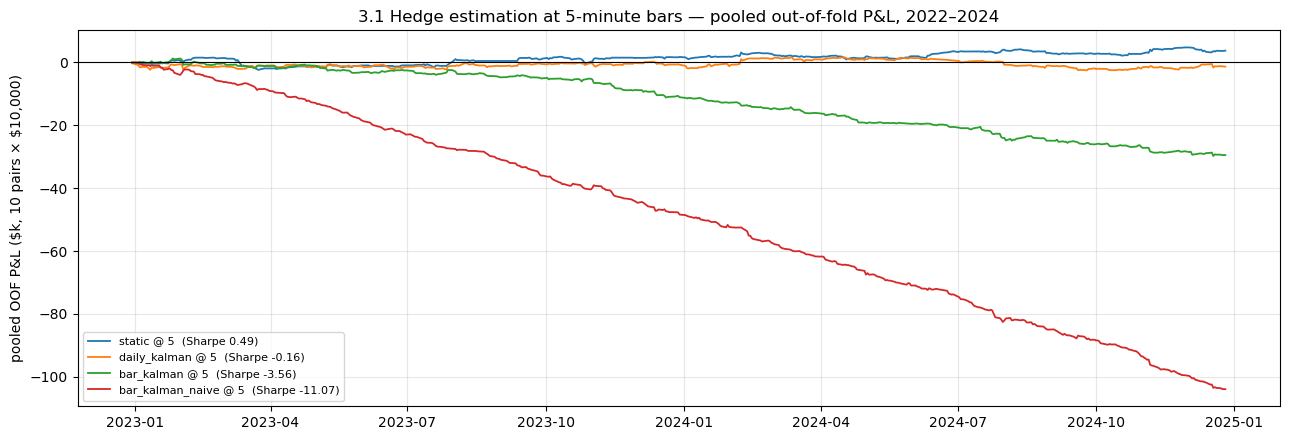

In [5]:
HEDGES = ["static", "daily_kalman", "bar_kalman", "bar_kalman_naive"]
res_hedge = [oof(h, 5, DEFAULT) for h in HEDGES]
display(table(res_hedge))
plot_equity(res_hedge, "3.1 Hedge estimation at 5-minute bars — pooled out-of-fold P&L, 2022–2024")

The ordering is the one notebook 15 predicted, and the mechanism is visible in the last two columns.
The **static** hedge leaves a residual whose half-life is weeks, so the rule picks a ~23-session look-back,
trades ~380 times in two years, holds for about a session, and comes out positive for eight of ten pairs.
Every faster hedge shortens the residual's memory and the look-back with it: the **daily-cadence Kalman**
(EM on session closes) halves the holding period and more than triples the trades; the
**frequency-scaled bar Kalman** re-estimates the hedge intraday and trades 4,800 times; the **naive
port** of the daily settings updates the hedge every 5 minutes, leaves white noise behind, and burns
$114k of costs on 20,000 trades. A Kalman filter is not wrong here — the daily notebooks use it well on daily bars — but on minute
bars its state absorbs the very reversion the strategy wants to trade, and the more often it updates the
less is left. The static hedge is carried forward.

### 3.2 Sampling frequency

hedge carried forward: static


,pooled OOF Sharpe,P&L ($k),costs ($k),trades,median hold (sessions),pairs +ve / 10,median pair Sharpe,median look-back (sessions)
label,,,,,,,,
static @ 1,0.64,5.15,4.05,608,0.09,7,0.36,21.13
static @ 5,0.49,3.75,2.50,382,1.00,8,0.42,22.79
static @ 15,0.95,6.58,1.85,286,1.88,8,0.54,23.33
static @ 30,1.50,10.11,1.48,229,2.69,8,0.82,22.31
static @ session,0.72,4.59,0.76,114,7.00,7,0.35,23.00


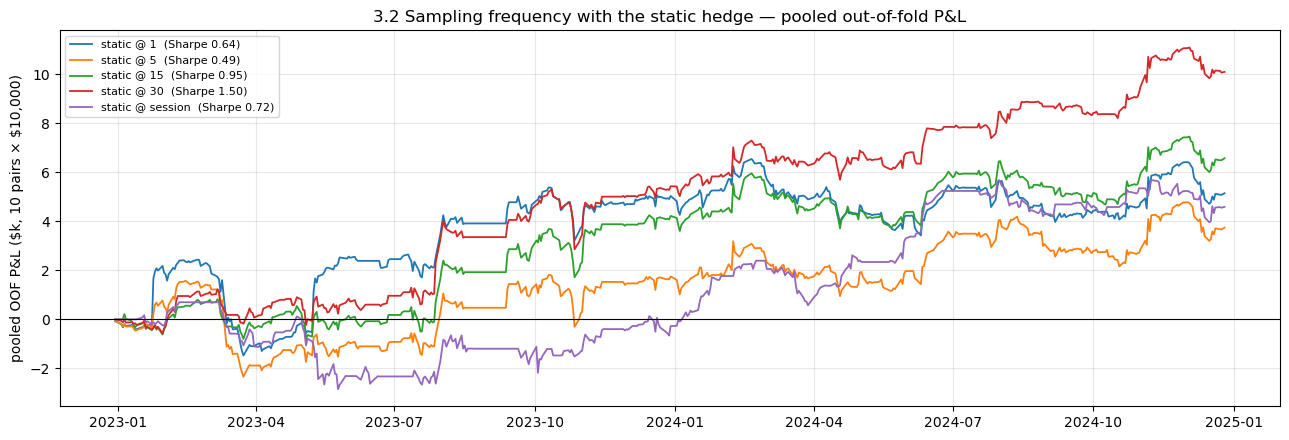

In [6]:
BEST_HEDGE = max(res_hedge, key=lambda r: r["sharpe"])["hedge"]
print("hedge carried forward:", BEST_HEDGE)
res_freq = [oof(BEST_HEDGE, k, DEFAULT) for k in (1, 5, 15, 30, "session")]
display(table(res_freq))
plot_equity(res_freq, f"3.2 Sampling frequency with the {BEST_HEDGE} hedge — pooled out-of-fold P&L")

Every frequency from one minute to a session sees the same ~22-session look-back — the spread's
half-life does not depend on how often it is sampled — so what changes is how finely the entry and exit
are timed and how much is paid for it. One-minute bars pay $4k of costs on 600 trades and still earn less
gross P&L than 30-minute bars, which pay $1.5k on 230; session closes are the cheapest but miss the
intraday excursions that the same look-back catches on a coarse intraday grid. Sharpe runs from 0.5
(5-minute) to 1.5 (30-minute) with daily bars at 0.7 — a range of about one and a half standard errors,
and not monotone in the sampling interval. What can be said is that minute resolution does not *hurt*
once the hedge is slow, and that the coarser intraday grids dominate the finer ones after costs.
30-minute bars are carried forward.

### 3.3 Session rule: overnight or intraday only

frequency carried forward: 30 min


,pooled OOF Sharpe,P&L ($k),costs ($k),trades,median hold (sessions),pairs +ve / 10,median pair Sharpe,median look-back (sessions)
label,,,,,,,,
overnight allowed,1.50,10.11,1.48,229,2.69,8,0.82,22.31
"flat by the close, no entry after 15:30",0.13,0.49,3.21,552,0.92,4,-0.08,22.31


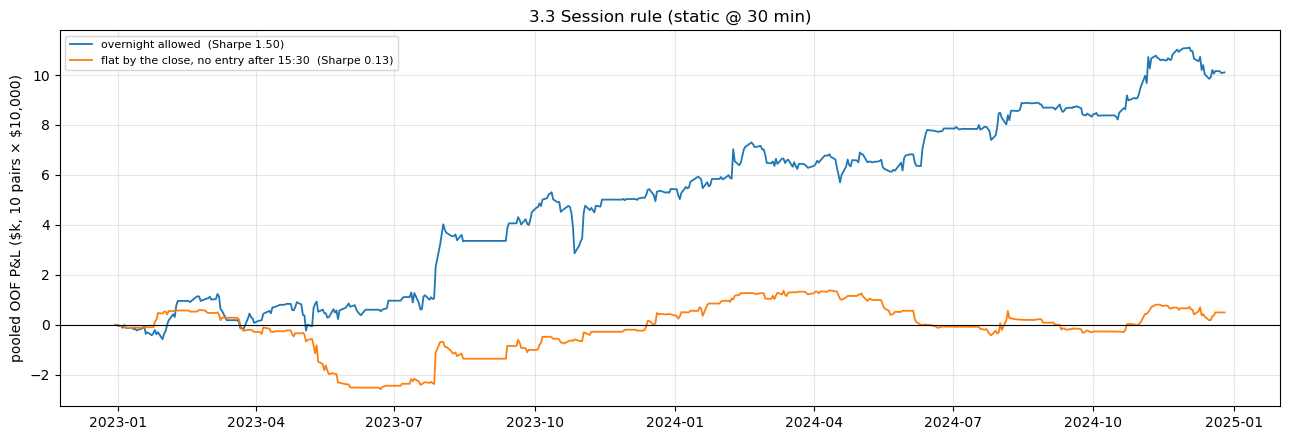

In [7]:
BEST_K = max((r for r in res_freq if r["k"] != "session"), key=lambda r: r["sharpe"])["k"]
print("frequency carried forward:", BEST_K, "min")
res_rule = [oof(BEST_HEDGE, BEST_K, DEFAULT, label="overnight allowed"),
            oof(BEST_HEDGE, BEST_K, {**DEFAULT, "flatten": True, "no_entry_after": "15:30"}, label="flat by the close, no entry after 15:30")]
display(table(res_rule))
plot_equity(res_rule, f"3.3 Session rule ({BEST_HEDGE} @ {BEST_K} min)")

Forcing positions flat by the close and blocking entries after 15:30 turns 1.5 into 0.1: two and a
half times the trades, twice the costs, a median hold of under a session against 2.7, and four positive
pairs instead of eight. Notebook 15 measured 40% of the spread's variance overnight; an intraday-only rule
gives that reversion up and pays to re-establish the position the next morning. These spreads are not an
intraday strategy, whatever the bar size.

### 3.4 Look-back and entry threshold

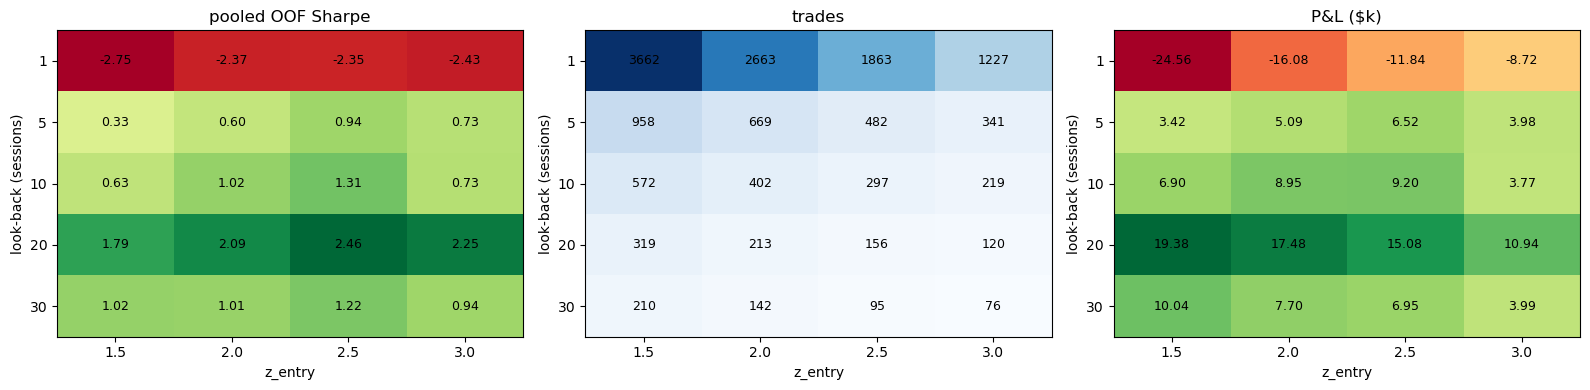

z_entry,1.5,2.0,2.5,3.0
lookback,,,,
1,-2.75,-2.37,-2.35,-2.43
5,0.33,0.60,0.94,0.73
10,0.63,1.02,1.31,0.73
20,1.79,2.09,2.46,2.25
30,1.02,1.01,1.22,0.94


best cell: look-back 20 sessions, entry 2.5 → pooled OOF Sharpe 2.46; default rule (3×half-life, entry 2.0): 1.50


In [8]:
LOOKBACKS, ENTRIES = [1, 5, 10, 20, 30], [1.5, 2.0, 2.5, 3.0]
grid = []
for lb, ze in itertools.product(LOOKBACKS, ENTRIES):
    r = oof(BEST_HEDGE, BEST_K, {**DEFAULT, "lookback": lb, "z_entry": ze}, label=f"look-back {lb} s, entry {ze}")
    grid.append({"lookback": lb, "z_entry": ze, "sharpe": r["sharpe"], "trades": r["trades"], "pnl_k": r["pnl_k"], "cost_k": r["cost_k"]})
grid = pd.DataFrame(grid)
piv = lambda v: grid.pivot(index="lookback", columns="z_entry", values=v)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, (v, t) in zip(ax, (("sharpe", "pooled OOF Sharpe"), ("trades", "trades"), ("pnl_k", "P&L ($k)"))):
    m = piv(v); im = a.imshow(m.to_numpy(), cmap="RdYlGn" if v != "trades" else "Blues", aspect="auto")
    a.set_xticks(range(len(ENTRIES))); a.set_xticklabels(ENTRIES); a.set_yticks(range(len(LOOKBACKS))); a.set_yticklabels(LOOKBACKS)
    a.set_xlabel("z_entry"); a.set_ylabel("look-back (sessions)"); a.set_title(t); a.grid(False)
    for i in range(len(LOOKBACKS)):
        for j in range(len(ENTRIES)): a.text(j, i, f"{m.iloc[i, j]:.2f}" if v != "trades" else f"{int(m.iloc[i, j])}", ha="center", va="center", fontsize=9)
plt.tight_layout(); plt.show()
display(piv("sharpe").round(2))
best = grid.loc[grid["sharpe"].idxmax()]
print(f"best cell: look-back {int(best.lookback)} sessions, entry {best.z_entry} → pooled OOF Sharpe {best.sharpe:.2f}; "
      f"default rule (3×half-life, entry 2.0): {res_rule[0]['sharpe']:.2f}")

The grid says two things, one solid and one suspect. Solid: a one-session look-back loses at every
threshold (Sharpe −2.3 to −2.8) — the economics of notebook 15 §6.4 in action, a short window scores
noise against a spread that reverts over weeks. Suspect: the 20-session row peaks at 1.8–2.5 while its
neighbours at 10 and 30 sessions sit at 0.6–1.3 and 0.9–1.2, and the half-life rule (a look-back that
varies by pair and fold around 22 sessions) gives 1.5. The whole positive region is within about one
standard error of the default, and a peak one row above its neighbours in a two-parameter grid evaluated
once on the same folds is what the winner's curse looks like, not what structure looks like; notebook 05
made the same point on daily bars with a much larger grid. The default rule is therefore what goes to the
hold-out, and the grid's best cell goes along only as the "tuned" comparison.

## 4. The design carried into notebook 17

* hedge: static OLS per fold, refitted every 20 sessions on the prior 250;
* bars: 30 minutes;
* rule: robust z-score, look-back 3 × half-life of the training residual (1–30 sessions), entry 2,
  exit 0.5, stop 4, positions carried overnight and across refits, next-bar execution;
* costs: 1 bp + half the Roll spread per leg per side, 50 bp/year borrow.

Pooled out-of-fold Sharpe 1.5 over 2023–2024 (s.e. ≈ 0.7), 229 trades, 8 of 10 pairs positive. The
grid's best cell (look-back 20 sessions, entry 2.5; 2.5) is recorded alongside for notebook 17.

In [9]:
design = {"hedge": BEST_HEDGE, "k": BEST_K,
          "cfg": DEFAULT,                                                                   # carried forward: the untuned rule
          "grid_cfg": {**DEFAULT, "lookback": int(best.lookback), "z_entry": float(best.z_entry)},   # the grid's best cell, for comparison
          "train_sessions": TRAIN_SESSIONS, "test_sessions": TEST_SESSIONS,
          "commission_bps": COMMISSION_BPS, "borrow_bps": BORROW_BPS, "cap": CAP,
          "oof_sharpe_default": res_rule[0]["sharpe"], "oof_sharpe_grid_best": float(best.sharpe)}
json.dump(design, open(CACHE / "min_design.json", "w"), indent=2, default=str)
print(json.dumps(design, indent=2, default=str))

{
  "hedge": "static",
  "k": 30,
  "cfg": {
    "lookback": null,
    "z_entry": 2.0,
    "z_exit": 0.5,
    "z_stop": 4.0,
    "flatten": false,
    "no_entry_after": null,
    "exec_lag": 1
  },
  "grid_cfg": {
    "lookback": 20,
    "z_entry": 2.5,
    "z_exit": 0.5,
    "z_stop": 4.0,
    "flatten": false,
    "no_entry_after": null,
    "exec_lag": 1
  },
  "train_sessions": 250,
  "test_sessions": 20,
  "commission_bps": 1.0,
  "borrow_bps": 50,
  "cap": 10000,
  "oof_sharpe_default": 1.5046958655936262,
  "oof_sharpe_grid_best": 2.4627172882055217
}
